In [3]:
%matplotlib inline
from __future__ import division
import matplotlib
import numpy as np
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import h5py
import os
matplotlib.rcParams.update({"axes.formatter.limits": (-4,4)})
plotStyles={"markersize":12,"markeredgewidth":3.0,"linewidth":3.0}
stepStyles={"markersize":12,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}
np.seterr(divide='ignore',invalid='ignore')
pass

### Execute with time limit.

In [9]:
%%bash
dirname=data/1
filename=${dirname}/first_order_birth_death.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_birth_death.sbml
lm_setp ${filename} writeInterval=1e-2 maxTime=1e1
echo "Execute the following command in `pwd`:"
lmes -r 1-2 -f ${filename} -gr 0


lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/1/first_order_birth_death.lm:
maxTime=1e1
writeInterval=1e-2
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/first_order_birth_death:
Lattice Microbe ES v2016.01.20 build 1 in 64-bit mode with options MPI.
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.

MPI version 3.0 with thread support MPI_THREAD_MULTIPLE.
Running with 1 process(es).

2016-00-26 11:28:43) Resource controller 0:1 started.
2016-00-26 11:28:43) Supervisor 0:2 started.
2016-00-26 11:28:43) Resource controller 

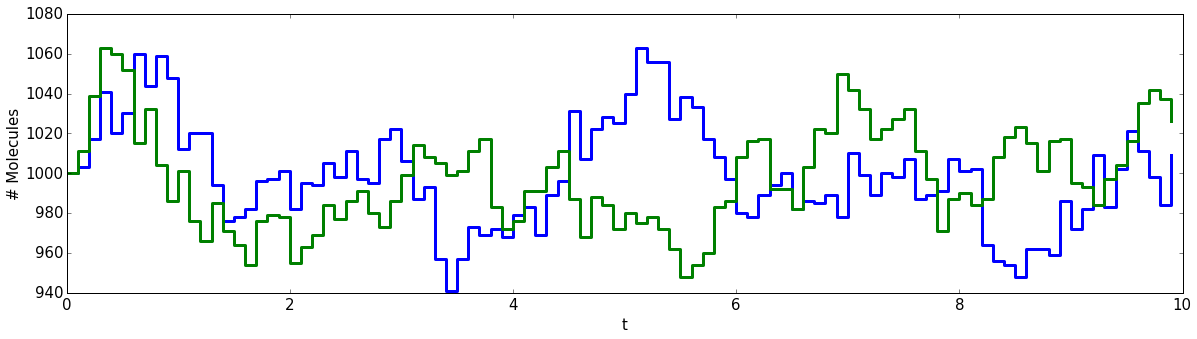

In [8]:
# Plot the time series for a single replicate.
dirname="data/1"
filename="%s/first_order_birth_death.lm"%dirname
fp = h5py.File(filename, "r")
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,5)})
replicate=1
counts=fp["/Simulations/%07d/SpeciesCounts"%replicate]
times=fp["/Simulations/%07d/SpeciesCountTimes"%replicate]
step(times[0:-1:10],counts[0:-1:10], **stepStyles)
replicate=2
counts=fp["/Simulations/%07d/SpeciesCounts"%replicate]
times=fp["/Simulations/%07d/SpeciesCountTimes"%replicate]
step(times[0:-1:10],counts[0:-1:10], **stepStyles)
xlabel('t'); ylabel('# Molecules')

### Performance comparison

Generate the input files and output the commands to run the simulations.

In [20]:
%%bash
dirname=data/perf
filename=${dirname}/first_order_birth_death.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_birth_death.sbml
lm_setp ${filename} writeInterval=1e4 maxTime=1e5
echo "Execute the following command in `pwd`:"
echo 'for replicate in `seq -f "%g" 0 10`; do'
echo "echo Running \${replicate};"
echo "lmes -r 1-10 -f ${filename} -c 2 -gr 0 -ff null| tee ${filename}.`hostname`.\${replicate}.log";
echo 'done;'


lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/perf/first_order_birth_death.lm:
maxTime=1e5
writeInterval=1e4
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/first_order_birth_death:
for replicate in `seq -f "%g" 0 10`; do
echo Running ${replicate};
lmes -r 1-10 -f data/perf/first_order_birth_death.lm -c 2 -gr 0 -ff null| tee data/perf/first_order_birth_death.lm.barkeri.local.${replicate}.log
done;
